# FGSM Attack on MNIST CNN

This notebook demonstrates the Fast Gradient Sign Method (FGSM) attack, a simple yet effective adversarial attack technique. We will:
1. Train a simple CNN on MNIST
2. Generate adversarial examples using FGSM
3. Visualize the perturbations and their effects

## Overview
- **FGSM**: Attacks that use the gradient of the loss with respect to the input to create adversarial examples
- **Epsilon**: The magnitude of the perturbation applied to images
- **Goal**: Understand how small perturbations can fool neural networks

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0
torchvision: 0.25.0


## 1. Data Preparation

Load and prepare the MNIST dataset with appropriate transformations.

In [ ]:
# Transform images to tensors
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 60000
Test size: 10000


### Explore Sample Data

Let's visualize a sample image from the training dataset to understand the data format.

In [16]:
image, label = train_dataset[0]

print("Label:", label)
print("Shape:", image.shape)
print("Min pixel:", image.min())
print("Max pixel:", image.max())

Label: 5
Shape: torch.Size([1, 28, 28])
Min pixel: tensor(0.)
Max pixel: tensor(1.)


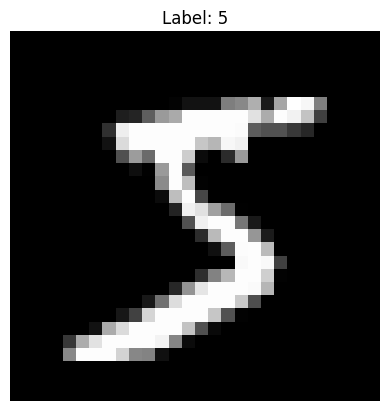

In [ ]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

### Create Data Loaders

Batch the data for efficient training and evaluation.

In [18]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

## 2. Model Architecture

Define a simple CNN model for MNIST classification. The architecture consists of:
- **Conv Layer 1**: 1 input channel → 32 filters (3×3 kernel)
- **Conv Layer 2**: 32 channels → 64 filters (3×3 kernel)
- **Fully Connected Layer 1**: 9216 → 128 neurons
- **Fully Connected Layer 2**: 128 → 10 output classes (digits 0-9)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3)   # 1 channel → 32 filters
        self.conv2 = nn.Conv2d(32, 64, 3)

        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        x = F.max_pool2d(x, 2)

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return F.log_softmax(x, dim=1)


model = SimpleCNN()

print(model)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


### Initialize Loss and Optimizer

Set up the loss function and optimizer for training.

In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 3. Training the Model

Train the CNN on the MNIST training dataset for multiple epochs. We'll track the loss to monitor training progress.

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 3

for epoch in range(epochs):

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.1445
Epoch 2, Loss: 0.0410
Epoch 3, Loss: 0.0255


## 4. Evaluate Model on Clean Data

Evaluate the trained model on the test dataset to establish a baseline accuracy before the adversarial attack.

In [23]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 98.98%


## 5. FGSM Attack

Implement the Fast Gradient Sign Method (FGSM) attack. This method generates adversarial examples by taking a step in the direction of the gradient of the loss with respect to the input.

### Step 1: Prepare Data for Attack

Select a batch of test images and set them to require gradients for the attack.

In [ ]:
epsilon = 0.25  # Perturbation magnitude

model.eval()

# Get a batch of test images
data_iter = iter(test_loader)
images, labels = next(data_iter)

images = images.to(device)
labels = labels.to(device)

# Enable gradients for input images (required for FGSM)
images.requires_grad = True

### Step 2: Compute Loss on Original Images

Forward pass through the model and compute the loss for the original (clean) images.

In [ ]:
outputs = model(images)
loss = criterion(outputs, labels)

### Step 3: Compute Gradients

Compute the gradient of the loss with respect to the input images.

In [ ]:
model.zero_grad()
loss.backward()

### Step 4: Generate Adversarial Perturbation

Create the adversarial perturbation by taking the sign of the gradient and scaling by epsilon.

In [ ]:
# Compute perturbation: epsilon * sign(gradient)
perturbation = epsilon * images.grad.sign()

# Add perturbation to original images
adv_images = images + perturbation

# Clip to valid pixel range [0, 1]
adv_images = torch.clamp(adv_images, 0, 1)

### Step 5: Evaluate Model on Adversarial Examples

Compare the model's predictions on adversarial examples with the true labels.

In [ ]:
outputs = model(adv_images)
_, predicted = torch.max(outputs, 1)

print("True labels:", labels[:10])
print("Predicted after attack:", predicted[:10])

True labels: tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])
Predicted after attack: tensor([7, 2, 4, 0, 4, 4, 8, 8, 6, 8])


## 6. Visualization

Visualize the original images, adversarial examples, and the perturbations applied to them.

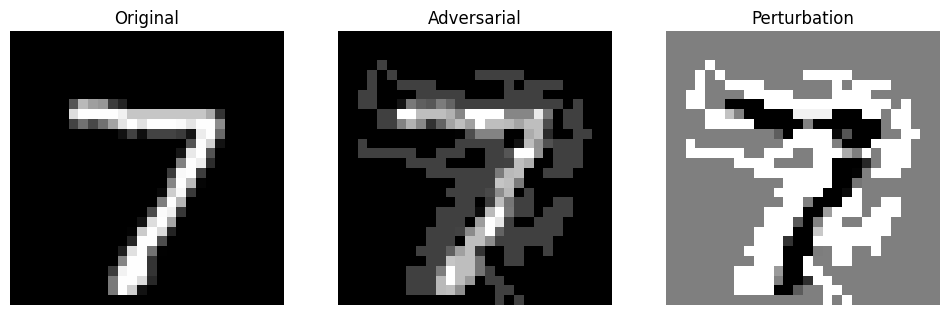

In [ ]:
idx = 0

# Get original and adversarial images
orig = images[idx].detach().cpu().squeeze()
adv = adv_images[idx].detach().cpu().squeeze()
diff = adv - orig

# Create visualization
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(orig, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Adversarial Image")
plt.imshow(adv, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Perturbation (Difference)")
plt.imshow(diff, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrates how the FGSM attack exploits gradients to create adversarial examples. Key observations:

- **Attack Effectiveness**: Small, imperceptible perturbations can cause the model to misclassify images
- **Epsilon Parameter**: Controls the magnitude of perturbation; higher epsilon leads to more visible changes
- **Gradient Importance**: The attack leverages the model's sensitivity to gradient direction
- **Robustness Challenge**: This highlights why building robust neural networks is critical for adversarial scenarios

Try experimenting with different epsilon values to see how the attack effectiveness changes!